In [1]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import logging

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books

# print(holdings.IBKR_live)

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

logging.getLogger().setLevel(logging.INFO)  # or INFO, ERROR, etc. SETS ROOT LEVEL LOGGING


print('ok')


ok


### run build_returns_weights
get the returns and prices dataframes

In [2]:

PORTFOLIO = 'IBKR_live' 
            # 'IBKR_live_adj'  
            # 'IBKR_sim' 
            # 'exp' 
holdings=getattr(books, PORTFOLIO)  # verify it exists

print('holdings:', holdings)

data_params = config.data_params
print('data_params:', data_params)
DEBUG = False

print('------\nBOOK:', PORTFOLIO, '\n-------')
max_age = data_params.get('max_age', 0)
print('max_age (hrs):', max_age, '\n-------')

rets_df, prices_df, w = risk_matrix.build_returns_weights(holdings, data_params=config.data_params, no_fx=True, usd_shift=False)

INFO:geoquant.risk_matrix:After alignment only 415 rows remain (expected 617). Data source may not have full history.
INFO:geoquant.risk_matrix:LOOKBACK DAYS/REGIME: 2024-09-01 to 2026-05-11  (617 days)


holdings: [{'name': 'XMWX', 'ticker': 'XMWX.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': False, 'position': 497, 'target_weight': 0.3}, {'name': 'EMIM', 'ticker': 'EMIM.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': True, 'position': 321, 'target_weight': 0.25}, {'name': 'GWX', 'ticker': 'GWX.US', 'ccy': 'USD', 'USD_exposure': 0.0, 'gbx': False, 'position': 203, 'target_weight': 0.15}, {'name': 'VUAG', 'ticker': 'VUAG.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': False, 'position': 39, 'target_weight': 0.1}, {'name': 'SGLN', 'ticker': 'SGLN.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'position': 68, 'target_weight': 0.08}, {'name': 'BATG', 'ticker': 'BATG.LSE', 'ccy': 'GBP', 'USD_exposure': 0.34, 'gbx': True, 'position': 173, 'target_weight': 0.12}, {'name': 'CASH_CHF', 'type': 'cash', 'ccy': 'CHF', 'amount': 11953, 'target_weight': 0.0}, {'name': 'CASH_JPY', 'ticker': 'JPYCHF.FOREX', 'type': 'cash', 'ccy': 'JPY', 'amount': 11416, 'target_weight': 0.0}, {'name': 'CASH_G

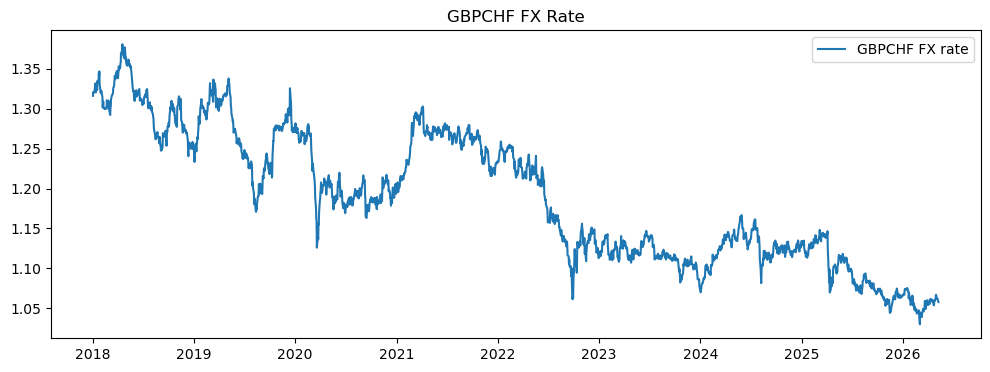

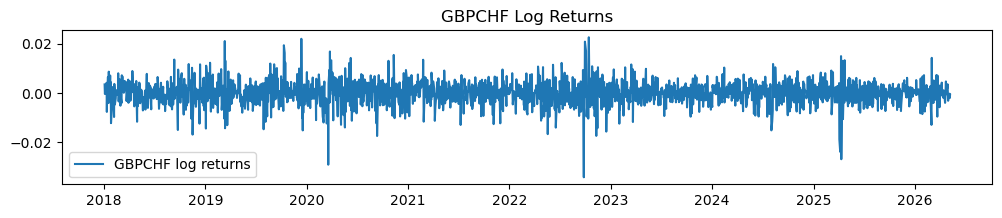

GBPCHF annualized vol: 0.07633364174559128


In [5]:
# --- Plot GBPCHF FX rate and log returns ---
fx_gbpchf = f1.fetch_csv('GBPCHF', data_params=config.data_params)
if 'close' in fx_gbpchf.columns:
    gbpchf = fx_gbpchf['close']
else:
    gbpchf = fx_gbpchf.iloc[:,0]  # fallback to first column if not named

plt.figure(figsize=(12, 4))
plt.plot(gbpchf.index, gbpchf, label='GBPCHF FX rate')
plt.title('GBPCHF FX Rate')
plt.legend()
plt.show()

# Plot GBPCHF log returns
import numpy as np
gbpchf_rets = np.log(gbpchf / gbpchf.shift(1))
plt.figure(figsize=(12, 2))
plt.plot(gbpchf_rets.index, gbpchf_rets, label='GBPCHF log returns')
plt.title('GBPCHF Log Returns')
plt.legend()
plt.show()

print('GBPCHF annualized vol:', gbpchf_rets.std() * np.sqrt(252))

## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [6]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","GWX","BATG","XMWX","SGLN", 'YCA', 'VUAG'] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(756))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.295032
2024-11-27    0.291555
2024-11-29    0.291390
2024-12-02    0.260760
2024-12-03    0.248151
                ...   
2026-05-01    0.468757
2026-05-05    0.465847
2026-05-06    0.471148
2026-05-07    0.470267
2026-05-08    0.462658
Length: 355, dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.230107
2024-11-27    0.226958
2024-11-29    0.226895
2024-12-02    0.196044
2024-12-03    0.184629
                ...   
2026-05-01    0.483970
2026-05-05    0.479640
2026-05-06    0.485137
2026-05-07    0.483915
2026-05-08    0.473644
Length: 355, dtype: float64


In [7]:

# Portfolio correlation matrix and risk summary
print('Correlation matrix:')
display(rets_df.corr())

risk_summary = risk_matrix.portfolio_risk(rets_df, w)
print('Portfolio risk summary:')
display(risk_summary)

# Display Percent Risk Contribution (PRC) column
import pandas as pd
pd.set_option('display.max_columns', None)
print('Percent Risk Contribution (PRC):')
display(risk_summary['PRC'])

Correlation matrix:


,XMWX,EMIM,GWX,VUAG,SGLN,BATG,YCA,CASH_CHF,CASH_JPY,CASH_GBP
XMWX,1.000000,0.216092,0.127312,0.544153,0.128944,0.182020,0.157336,NaN,0.028927,0.052310
EMIM,0.216092,1.000000,0.487661,0.239965,0.187236,0.726460,0.405874,NaN,-0.106310,0.013880
GWX,0.127312,0.487661,1.000000,0.132326,0.219106,0.413786,0.254904,NaN,0.050036,0.280582
VUAG,0.544153,0.239965,0.132326,1.000000,0.061262,0.214568,0.211049,NaN,-0.053771,0.015712
SGLN,0.128944,0.187236,0.219106,0.061262,1.000000,0.189535,0.234285,NaN,-0.007667,-0.145908
BATG,0.182020,0.726460,0.413786,0.214568,0.189535,1.000000,0.430517,NaN,-0.091421,0.044910
YCA,0.157336,0.405874,0.254904,0.211049,0.234285,0.430517,1.000000,NaN,-0.065003,0.006638
CASH_CHF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASH_JPY,0.028927,-0.106310,0.050036,-0.053771,-0.007667,-0.091421,-0.065003,NaN,1.000000,0.314327
CASH_GBP,0.052310,0.013880,0.280582,0.015712,-0.145908,0.044910,0.006638,NaN,0.314327,1.000000


INFO:geoquant.risk_matrix:++++++ portfolio_risk()


Portfolio risk summary:


{'port_vol': 0.22403979627197526,
 'cov_annual':               XMWX      EMIM       GWX      VUAG      SGLN      BATG  \
 XMWX      0.435614  0.022894  0.013673  0.170296  0.018126  0.031484   
 EMIM      0.022894  0.025767  0.012738  0.018265  0.006401  0.030561   
 GWX       0.013673  0.012738  0.026480  0.010210  0.007594  0.017646   
 VUAG      0.170296  0.018265  0.010210  0.224835  0.006187  0.026664   
 SGLN      0.018126  0.006401  0.007594  0.006187  0.045360  0.010579   
 BATG      0.031484  0.030561  0.017646  0.026664  0.010579  0.068683   
 YCA       0.037161  0.023315  0.014844  0.035812  0.017856  0.040376   
 CASH_CHF  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 CASH_JPY  0.001511 -0.001350  0.000644 -0.002018 -0.000129 -0.001896   
 CASH_GBP  0.002329  0.000150  0.003080  0.000503 -0.002096  0.000794   
 
                YCA  CASH_CHF  CASH_JPY  CASH_GBP  
 XMWX      0.037161       0.0  0.001511  0.002329  
 EMIM      0.023315       0.0 -0.001350  0.

Percent Risk Contribution (PRC):


KeyError: 'PRC'